In [87]:
import joblib
from datasets import load_dataset
import sys
import pandas as pd
import matplotlib.pyplot as plt


## Создание AudioPreprocessor

In [88]:
sys.path.append("..")

from utils.feature_extractor import SpectralFeatureExtractor, FrontendConfig
from utils.stream_preprocessor import AudioPreprocessor

In [89]:
model = joblib.load("../models/logistic_regression_kws.pkl")
threshold = joblib.load("../models/threshold.pkl")

print(model)
print(threshold)


Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(C=np.float64(2.1544346900318843),
                                    max_iter=3000, penalty='l1',
                                    random_state=42, solver='liblinear'))])
0.45


## Обработка произвольного аудиофайла

In [90]:
def save_plot(filename):
    plt.tight_layout()
    plt.savefig(f"../img/{filename}", dpi=300, bbox_inches="tight")
    plt.show()

In [91]:
def run_stream_inference(
    model,
    audio_path,
    threshold,
    smooth_window=2,
    debounce_sec=1.5,
    show_plots=True,
    plt_name=""
):
    """
    Run streaming keyword spotting on an audio file.

    Parameters
    ----------
    model : trained classifier
        Trained model with predict_proba().
    audio_path : str
        Path to audio file.
    threshold : float
        Detection threshold.
    smooth_window : int, default=2
        Moving average window size.
    debounce_sec : float, default=1.5
        Minimum time between detections.
    show_plots : bool, default=True
        Whether to display the probability plot.

    Returns
    -------
    detections_df : pd.DataFrame
    stream_results : pd.DataFrame
    """

    pre = AudioPreprocessor(
        SpectralFeatureExtractor(FrontendConfig()),
        window_sec=1.0,
        hop_sec=0.1
    )

    timestamps, X_stream = pre.process_file(audio_path)

    probabilities = model.predict_proba(X_stream)[:, 1]
    predictions = (probabilities >= threshold).astype(int)

    stream_results = pd.DataFrame({
        "time_sec": timestamps,
        "probability": probabilities,
        "prediction": predictions
    })

    stream_results["probability_smooth"] = (
        stream_results["probability"]
        .rolling(window=smooth_window, center=True, min_periods=1)
        .mean()
    )

    detections = []
    last_detection_time = -float("inf")

    for _, row in stream_results.iterrows():

        detected = (
            row["probability"] >= threshold
            or row["probability_smooth"] >= threshold
        )

        if detected and (row["time_sec"] - last_detection_time) >= debounce_sec:
            detections.append({
                "time_sec": row["time_sec"],
                "raw_probability": row["probability"],
                "smooth_probability": row["probability_smooth"]
            })

            last_detection_time = row["time_sec"]

    detections_df = pd.DataFrame(detections)

    if show_plots:
        plt.figure(figsize=(12, 4))

        plt.plot(
            stream_results["time_sec"],
            stream_results["probability"],
            alpha=0.35,
            label="Raw probability"
        )

        plt.plot(
            stream_results["time_sec"],
            stream_results["probability_smooth"],
            label="Smoothed probability"
        )

        plt.axhline(
            threshold,
            linestyle="--",
            label=f"Threshold = {threshold:.2f}"
        )

        for _, row in detections_df.iterrows():
            plt.axvline(row["time_sec"], linestyle=":", alpha=0.8)

        plt.xlabel("Time (seconds)")
        plt.ylabel("Probability")
        plt.title("Streaming Inference")
        plt.grid(True)
        plt.legend()
        if plt_name:
            save_plot(f"{plt_name}.png")
        plt.show()

    if detections_df.empty:
        print("Keyword was not detected.")
    else:
        for _, row in detections_df.iterrows():
            print(
                f"Keyword detected at {row['time_sec']:.2f}s | "
                f"raw = {row['raw_probability']:.3f} | "
                f"smooth = {row['smooth_probability']:.3f}"
            )

    return detections_df, stream_results

/Users/ainurakerimkulova/Documents/Data Scince/ kws-project/kws-project/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


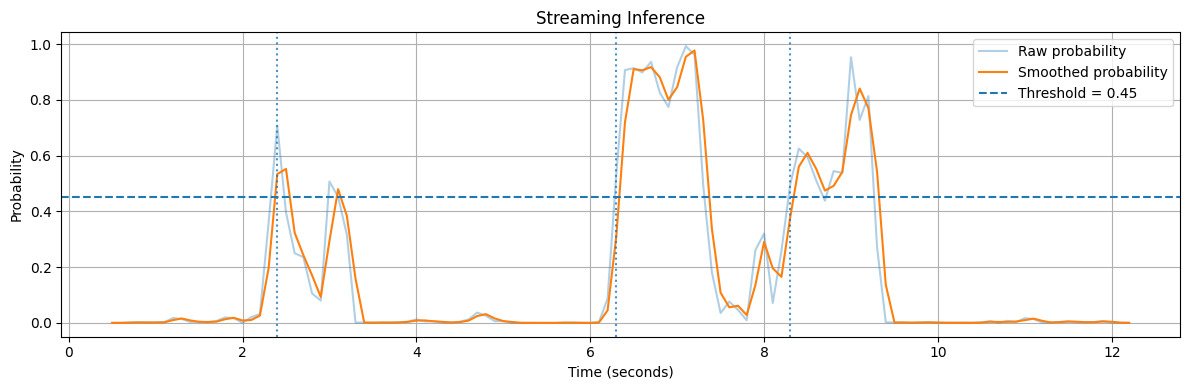

Keyword detected at 2.40s | raw = 0.708 | smooth = 0.534
Keyword detected at 6.30s | raw = 0.533 | smooth = 0.310
Keyword detected at 8.30s | raw = 0.496 | smooth = 0.377


(   time_sec  raw_probability  smooth_probability
 0       2.4         0.708238            0.533917
 1       6.3         0.533424            0.310373
 2       8.3         0.495861            0.377401,
      time_sec  probability  prediction  probability_smooth
 0         0.5     0.000081           0            0.000081
 1         0.6     0.000039           0            0.000060
 2         0.7     0.001426           0            0.000733
 3         0.8     0.001883           0            0.001655
 4         0.9     0.001191           0            0.001537
 ..        ...          ...         ...                 ...
 113      11.8     0.002929           0            0.002674
 114      11.9     0.006973           0            0.004951
 115      12.0     0.001215           0            0.004094
 116      12.1     0.000393           0            0.000804
 117      12.2     0.000036           0            0.000214
 
 [118 rows x 4 columns])

In [92]:
audio_path = "../2026-06-07 20.33.07.wav"
run_stream_inference(
    model=model,
    audio_path=audio_path,
    threshold=threshold,
    smooth_window=2,
    debounce_sec=1.5,
    show_plots=True,
    plt_name="streaming_inference_plot"
)

/Users/ainurakerimkulova/Documents/Data Scince/ kws-project/kws-project/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


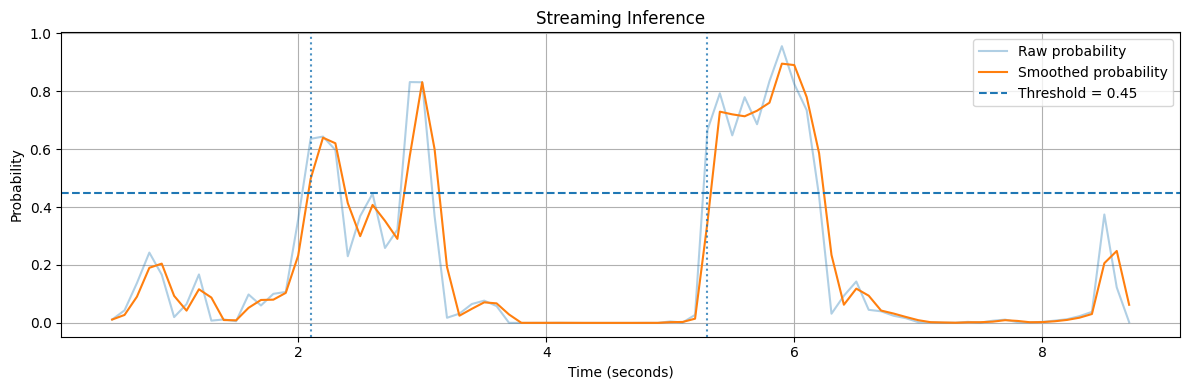

Keyword detected at 2.10s | raw = 0.635 | smooth = 0.496
Keyword detected at 5.30s | raw = 0.666 | smooth = 0.347


(   time_sec  raw_probability  smooth_probability
 0       2.1         0.635346            0.496350
 1       5.3         0.665897            0.346772,
     time_sec  probability  prediction  probability_smooth
 0        0.5     0.011487           0            0.011487
 1        0.6     0.043255           0            0.027371
 2        0.7     0.137630           0            0.090443
 3        0.8     0.242685           0            0.190157
 4        0.9     0.166475           0            0.204580
 ..       ...          ...         ...                 ...
 78       8.3     0.023253           0            0.017974
 79       8.4     0.038039           0            0.030646
 80       8.5     0.374140           0            0.206089
 81       8.6     0.122485           0            0.248313
 82       8.7     0.002329           0            0.062407
 
 [83 rows x 4 columns])

In [93]:
path = "../20260702_200722516.wav"
run_stream_inference(
    model=model,
    audio_path=path,
    threshold=threshold,
    smooth_window=2,
    debounce_sec=1.5,
    show_plots=True,
    plt_name="streaming_inference_plot_2"
)